# Predicción de Pedidos Cancelados: Del Análisis de Datos al Modelado

Este proyecto tiene como objetivo principal desarrollar un modelo de aprendizaje automático capaz de anticipar si un pedido será entregado o cancelado. Para lograr una predicción precisa, el trabajo se fundamenta en el análisis detallado de las variables del negocio, lo que nos permite identificar qué factores y comportamientos en los datos influyen realmente en la cancelación de una venta.

En este notebook, daremos respuesta a la pregunta: ¿Podemos predecir qué pedidos serán cancelados antes de procesarlos? Con este fin, utilizaremos los hallazgos obtenidos en nuestra exploración de variables para construir y comparar diferentes modelos de clasificación, evaluando cuál de ellos ofrece los mejores resultados para optimizar la toma de decisiones.

## Librerías, configuraciones y carga de datos

In [ ]:
# Importación de datos y análisis exploratorio inicial
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Transformación y preparación de datos
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

In [2]:
# Configuración de colores y estilos de las graficas
color_entregado = "#4E79A7"
color_cancelado = "#E15759"
mis_colores_multi = ["#4E79A7", "#E15759", "#76B7B2", "#59A14F", "#EDC948", "#B07AA1", "#FF9DA7", "#9C755F"]

sns.set_theme(style="whitegrid", rc={"axes.facecolor": "#FBFBFB", "grid.color": "#ECECEC"})
sns.set_palette(sns.color_palette(mis_colores_multi))

order_status_palette = {'Delivered': color_entregado, 'Cancelled': color_cancelado}

In [3]:
df = pd.read_csv('../../Data/Amazon.csv')
df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


## Limpieza y transformación de datos

Primeramente lo que haremos sera la correción de las variables "City" y "State", ya que, los datos que estan nombrados en los paises que se diferencian de 'United States', tienen los nombres de las ciudades y estados que pertenecen a este, lo que significaria para el modelo, algun tipo de sobreajuste o incoherencia en sus metricas al tratar de predecir la cancelación de una ciudad pero escogiendo al azar uno de los paises que esta en el dataset.

**Nota:** Esta imputación se realiza exclusivamente para fines de estabilidad del modelo en este entorno de desarrollo. En un entorno productivo real, se requeriría una validación con la fuente de origen de los datos (logs de GPS o bases de datos postales).

In [4]:
datos_geograficos = {
    'Canada': [
        ('Toronto', 'ON'), ('Ottawa', 'ON'), ('Hamilton', 'ON'), ('London', 'ON'), 
        ('Montreal', 'QC'), ('Quebec City', 'QC'), ('Laval', 'QC'),
        ('Vancouver', 'BC'), ('Victoria', 'BC'), ('Surrey', 'BC'),
        ('Calgary', 'AB'), ('Edmonton', 'AB'),
        ('Winnipeg', 'MB'), ('Saskatoon', 'SK'), ('Halifax', 'NS'),
        ('Moncton', 'NB'), ('St. Johns', 'NL'), ('Charlottetown', 'PE'),
        ('Whitehorse', 'YT'), ('Yellowknife', 'NT')
    ],
    'Australia': [
        ('Sydney', 'NSW'), ('Newcastle', 'NSW'), ('Wollongong', 'NSW'),
        ('Melbourne', 'VIC'), ('Geelong', 'VIC'), ('Ballarat', 'VIC'),
        ('Brisbane', 'QLD'), ('Gold Coast', 'QLD'), ('Townsville', 'QLD'), ('Cairns', 'QLD'),
        ('Perth', 'WA'), ('Adelaide', 'SA'), ('Hobart', 'TAS'),
        ('Darwin', 'NT'), ('Canberra', 'ACT'), ('Sunshine Coast', 'QLD'),
        ('Toowoomba', 'QLD'), ('Bendigo', 'VIC'), ('Launceston', 'TAS'), ('Albury', 'NSW')
    ],
    'India': [
        ('Mumbai', 'MH'), ('Pune', 'MH'), ('Nagpur', 'MH'), ('Thane', 'MH'),
        ('Delhi', 'DL'), ('New Delhi', 'DL'),
        ('Bangalore', 'KA'), ('Mysore', 'KA'),
        ('Chennai', 'TN'), ('Madurai', 'TN'),
        ('Kolkata', 'WB'), ('Howrah', 'WB'),
        ('Hyderabad', 'TG'), ('Ahmedabad', 'GJ'), ('Surat', 'GJ'),
        ('Jaipur', 'RJ'), ('Lucknow', 'UP'), ('Kanpur', 'UP'),
        ('Patna', 'BR'), ('Indore', 'MP')
    ],
    'United Kingdom': [
        ('London', 'LDN'), ('Westminster', 'LDN'),
        ('Birmingham', 'WM'), ('Coventry', 'WM'),
        ('Manchester', 'GMC'), ('Salford', 'GMC'),
        ('Glasgow', 'SCT'), ('Edinburgh', 'SCT'), ('Aberdeen', 'SCT'),
        ('Liverpool', 'MSY'), ('Leeds', 'WYK'), ('Bradford', 'WYK'),
        ('Sheffield', 'SYK'), ('Bristol', 'BST'), ('Belfast', 'NIR'),
        ('Cardiff', 'WLS'), ('Swansea', 'WLS'), ('Leicester', 'LEC'),
        ('Nottingham', 'NTT'), ('Southampton', 'HAM')
    ]
}

def aplicar_limpieza_geografica(df):
    df_clean = df.copy()
    
    for pais, lista_geo in datos_geograficos.items():
        mask_pais = df_clean['Country'] == pais
        indices = df_clean[mask_pais].index
        
        if len(indices) > 0:
            idx_aleatorios = np.random.choice(len(lista_geo), size=len(indices))
            selecciones = [lista_geo[i] for i in idx_aleatorios]
            
            # Asignación masiva de Ciudad y Estado
            df_clean.loc[indices, 'City'] = [s[0] for s in selecciones]
            df_clean.loc[indices, 'State'] = [s[1] for s in selecciones]
            
            print(f"✅ Procesados {len(indices)} registros de {pais} (20 ciudades, 13 estados).")
            
    return df_clean

# Ejecución
df_cleaned = aplicar_limpieza_geografica(df)

✅ Procesados 5818 registros de Canada (20 ciudades, 13 estados).
✅ Procesados 4130 registros de Australia (20 ciudades, 13 estados).
✅ Procesados 15051 registros de India (20 ciudades, 13 estados).
✅ Procesados 4943 registros de United Kingdom (20 ciudades, 13 estados).


Despues de esta limpieza, lo que haremos sera exportar este dataset con la transformación realizada para no tener que repetir este paso en los siguientes notebooks.

In [9]:
df_cleaned.to_parquet('../../Data/Amazon_cleaned.parquet', index=False)

## Creación y transformación de variables para análisis exploratorio y modelado

Ahora, lo que haremos sera seleccionar la variable objetivo, en este caso es la variable "OrderStatus", con lo cual tomaremos los valores de "Cancelled" como 1, ya que representan los datos que necesitariamos analizar al ser pedidos con perdida para la empresa, y los valores de "Delivered" los tomaremos como 0. descartamos los otros valores ya que no nos aportaria mucho al crear el modelo y podria generarnos algun tipo de sesgo, porque al ser datos de pedidos devueltos, enviados y pendientes, no determina con exactitud si el pedido fue cancelado o no. Tambien, creamos las nuevas columnas de "Month" y "Day" a partir de la columna "OrderDate", para hacerles un análisis mas detallado a las fechas de los pedidos. Finalmente, creamos la columna "TotalAmount" para clasificar los precios de cada producto sin contar los descuentos y el tax.

In [10]:
df_cleaned = pd.read_parquet('../../Data/Amazon_cleaned.parquet')

df_analisis = df_cleaned[~df_cleaned["OrderStatus"].isin(['Pending', 'Returned', 'Shipped'])].copy()
df_analisis["target"] = np.where(df_analisis["OrderStatus"] == 'Cancelled', 1, 0)

# Creación de la columna 'Month'
df_analisis['Month'] = pd.to_datetime(df_analisis['OrderDate']).dt.month

# Creación de la columna 'Day'
df_analisis['Day'] = pd.to_datetime(df_analisis['OrderDate']).dt.dayofweek

# Creación de la columna 'Product_Value' basada en cuantiles de 'UnitPrice' 
df_analisis['Product_Value'] = (pd.qcut(df_analisis['UnitPrice'], q=3, labels=[1, 2, 3])) # 1: Económico, 2: Estándar, 3: Premium
df_analisis['Product_Value'] = df_analisis['Product_Value'].astype(int) 

## Análisis exploratorio de datos (EDA)

Como primer inspección que queremoa hacer de los datos, veremos la distribución de los datos 'entregados' y 'cancelados' para ver si hay un balance adecuado entre las clases.

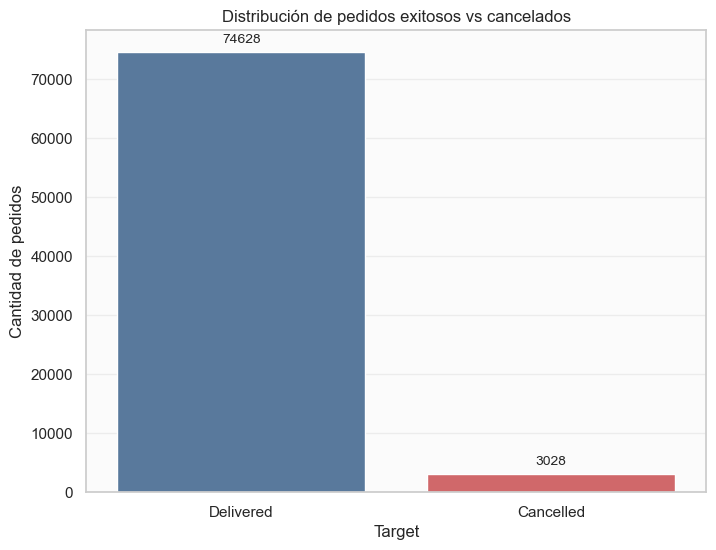

In [11]:
plt.figure(figsize=(8, 6))
g = sns.countplot(data=df_analisis, x='OrderStatus', hue='OrderStatus', palette=order_status_palette, legend=False)
for container in g.containers:
    g.bar_label(container, fmt='%d', padding=5, fontsize=10)

plt.xlabel("Target")
plt.ylabel("Cantidad de pedidos")
plt.title("Distribución de pedidos exitosos vs cancelados")
plt.show()

Vemos como hay un claro desbalance entre las clases, con lo cual, al momento de entrenar los modelos, realizaremos tecnicas para balancear los datos. Seguidamente, haremos una exploracion de las variables que mas llamen la atencion y puedan ser utiles para tener una idea de cuales podrian ser las mas relevantes para predecir la variable objetivo y tener las mejores metricas posibles.

A continuación, veremos la distribución de cada pedido ya sea entregado o cancelado por medio de la variable "UnitPrice" para ver si al tener una cantidad mayor de pedidos entregados, el promedio de entrega es mayor que los cancelados, lo cual, nos podria ayudar para que el modelo en su entrenamiento pueda notar algo de diferencia por su distribución.

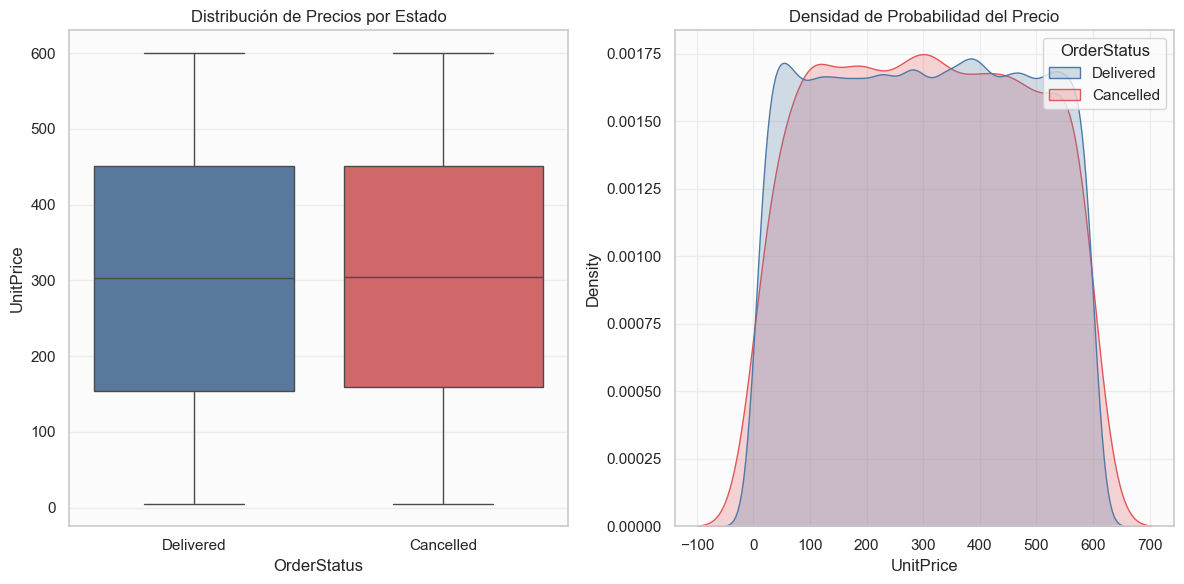

In [ ]:
plt.figure(figsize=(12, 6))

# Boxplot para ver valores atípicos (outliers)
plt.subplot(1, 2, 1)
sns.boxplot(x='OrderStatus', y='UnitPrice',hue = 'OrderStatus', data=df_analisis, palette=order_status_palette)
plt.title('Distribución de Precios por Estado')

# KDE Plot para ver la forma de la distribución
plt.subplot(1, 2, 2)
sns.kdeplot(data=df_analisis, x="UnitPrice", hue="OrderStatus", fill=True, common_norm=False, palette=order_status_palette)
plt.title('Densidad de Probabilidad del Precio')

plt.tight_layout()
plt.show()

Notamos que a pesar de que la mayoria de pedidos son exitosos, tienen el mismo promedio en ventas y una distribución centrada, lo cual, podria podria ser un factor que el modelo no diferencie tanto las categorias por medio de esta variable.

Ahora, analizaremos la varaible "Month" para ver si los pedidos cancelados pueden variar en función del mes en el que se realizaron.

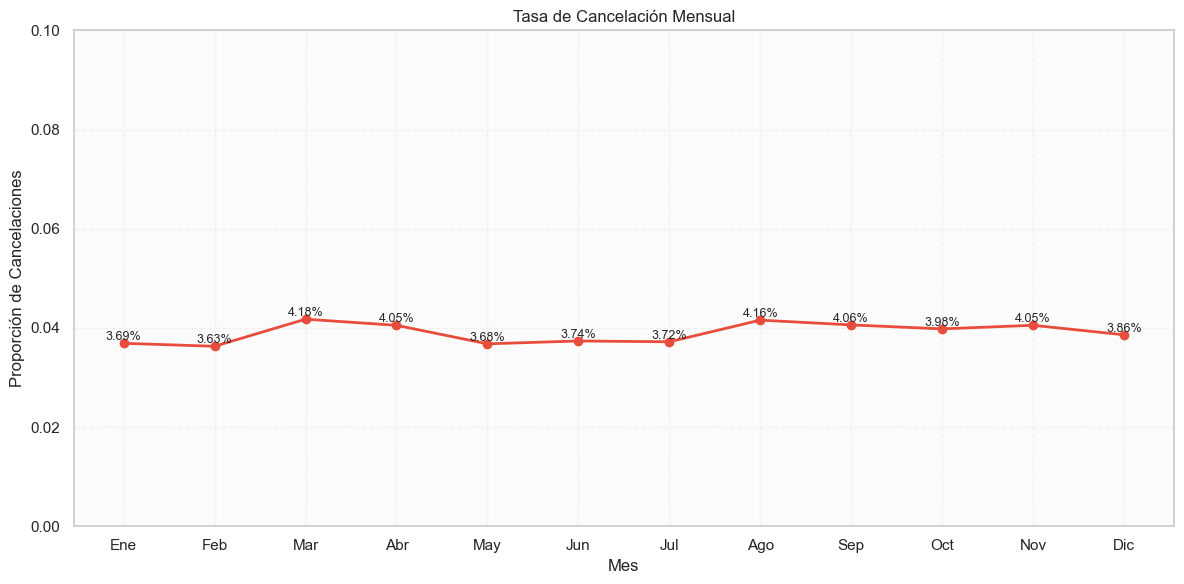

In [9]:
monthly_stats = df_analisis.groupby('Month')['target'].value_counts(normalize=True).unstack(fill_value=0).sort_values(by='Month', ascending=True)

if 1 in monthly_stats.columns:
    tasa_interes = monthly_stats[1]
else:
    tasa_interes = monthly_stats['Cancelled']

plt.figure(figsize=(12, 6))
plt.plot(monthly_stats.index, tasa_interes, 
         marker='o', color='#e74c3c', linewidth=2)
plt.xticks(range(1, 13), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])

for x, y in zip(monthly_stats.index, tasa_interes):
    plt.text(x, y, f'{y:.2%}', ha='center', va='bottom', fontsize=9)

plt.ylim(0, 0.10)
plt.title('Tasa de Cancelación Mensual')
plt.xlabel('Mes')
plt.ylabel('Proporción de Cancelaciones')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Como se observa en el análisis, los meses no presentan una variación significativa en la tasa de pedidos cancelados, manteniéndose una proporción de pérdidas relativamente constante a lo largo del año. Esta estabilidad es un indicador positivo para la organización, ya que sugiere una gestión operativa controlada. Lo anterior permite concluir que la empresa ha logrado mantener una consistencia sólida en sus procesos logísticos y de mitigación de riesgos, logrando que factores estacionales no impacten negativamente en la efectividad de las entregas.

Por esta razón, el siguiente paso será analizar las cancelaciones por país y ciudad en relación con las categorías de productos. El objetivo es identificar si existen zonas específicas donde se cancelen más pedidos de lo normal y verificar si esto sucede con algún tipo de producto en particular; de esta manera, podremos entender mejor en qué lugares y con qué mercancía se están presentando los mayores inconvenientes

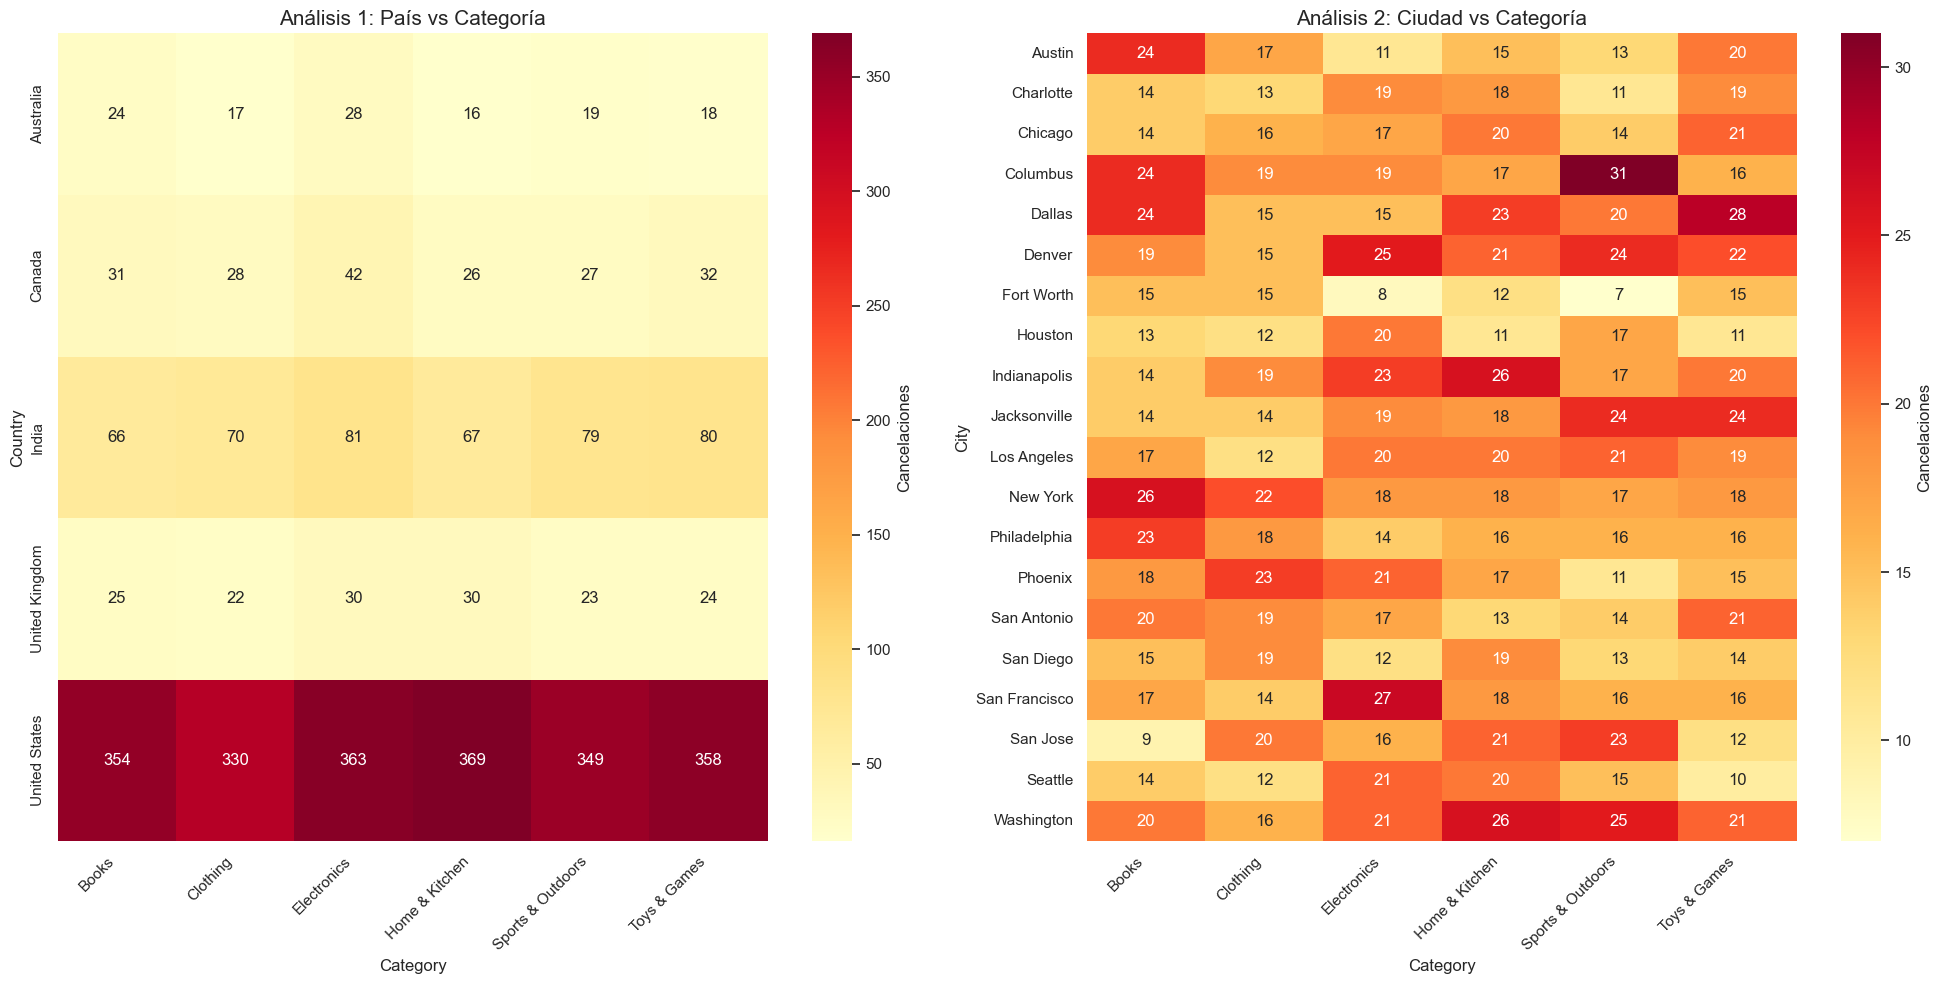

In [10]:
# Filtrar solo los registros con cancelaciones
cancelled = df_analisis[df_analisis['target'] == 1].copy()

# Configuración gráfica 1: País vs Categoría
top_rows_1 = cancelled['Country'].value_counts().nlargest(10).index
top_cols_1 = cancelled['Category'].value_counts().nlargest(15).index

subset1 = cancelled[cancelled['Country'].isin(top_rows_1) & cancelled['Category'].isin(top_cols_1)]
pivot1 = pd.crosstab(subset1['Country'], subset1['Category'])

# Configuración gráfica 2: Ciudad vs Categoría
top_rows_2 = cancelled['City'].value_counts().nlargest(20).index
top_cols_2 = cancelled['Category'].value_counts().nlargest(10).index

subset2 = cancelled[cancelled['City'].isin(top_rows_2) & cancelled['Category'].isin(top_cols_2)]
pivot2 = pd.crosstab(subset2['City'], subset2['Category'])

# Graficas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Heatmap 1: Por País
sns.heatmap(pivot1, annot=True, fmt='d', cmap='YlOrRd', ax=ax1, cbar_kws={'label': 'Cancelaciones'})
ax1.set_title('Análisis 1: País vs Categoría', fontsize=15)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Heatmap 2: Por Ciudad
sns.heatmap(pivot2, annot=True, fmt='d', cmap='YlOrRd', ax=ax2, cbar_kws={'label': 'Cancelaciones'})
ax2.set_title('Análisis 2: Ciudad vs Categoría', fontsize=15)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

Al analizar la distribución geográfica mediante mapas de calor, se observa que Estados Unidos presenta un volumen de actividad significativamente mayor que el resto de los países. Sin embargo, se ha identificado que cada país mantiene un comportamiento muy similar entre sus categorías de productos; esto explica por qué las pérdidas mensuales son constantes, ya que se reparten de manera uniforme en todo el catálogo. Además, a nivel local, el análisis de ciudades muestra que cada ubicación suele tener una o dos categorías con mayor cantidad de cancelaciones. Este dato es clave para diseñar planes estratégicos que busquen reducir las pérdidas de forma específica, atacando los problemas particulares de cada ciudad.

Con este contexto, el siguiente paso consistirá en calcular la Tasa de fallo (ratio %) de cancelación para cuatro variables fundamentales: país, método de pago, categoría y marca. El propósito de este análisis es determinar si las cifras elevadas en ciertos segmentos, como ocurre con Estados Unidos, representan realmente un nivel de pérdida preocupante o si son simplemente proporcionales a su alto volumen de ventas. Al utilizar esta métrica de proporción, podremos identificar con exactitud qué factores presentan un problema de efectividad real y cuáles destacan únicamente por ser los más utilizados o vendidos.

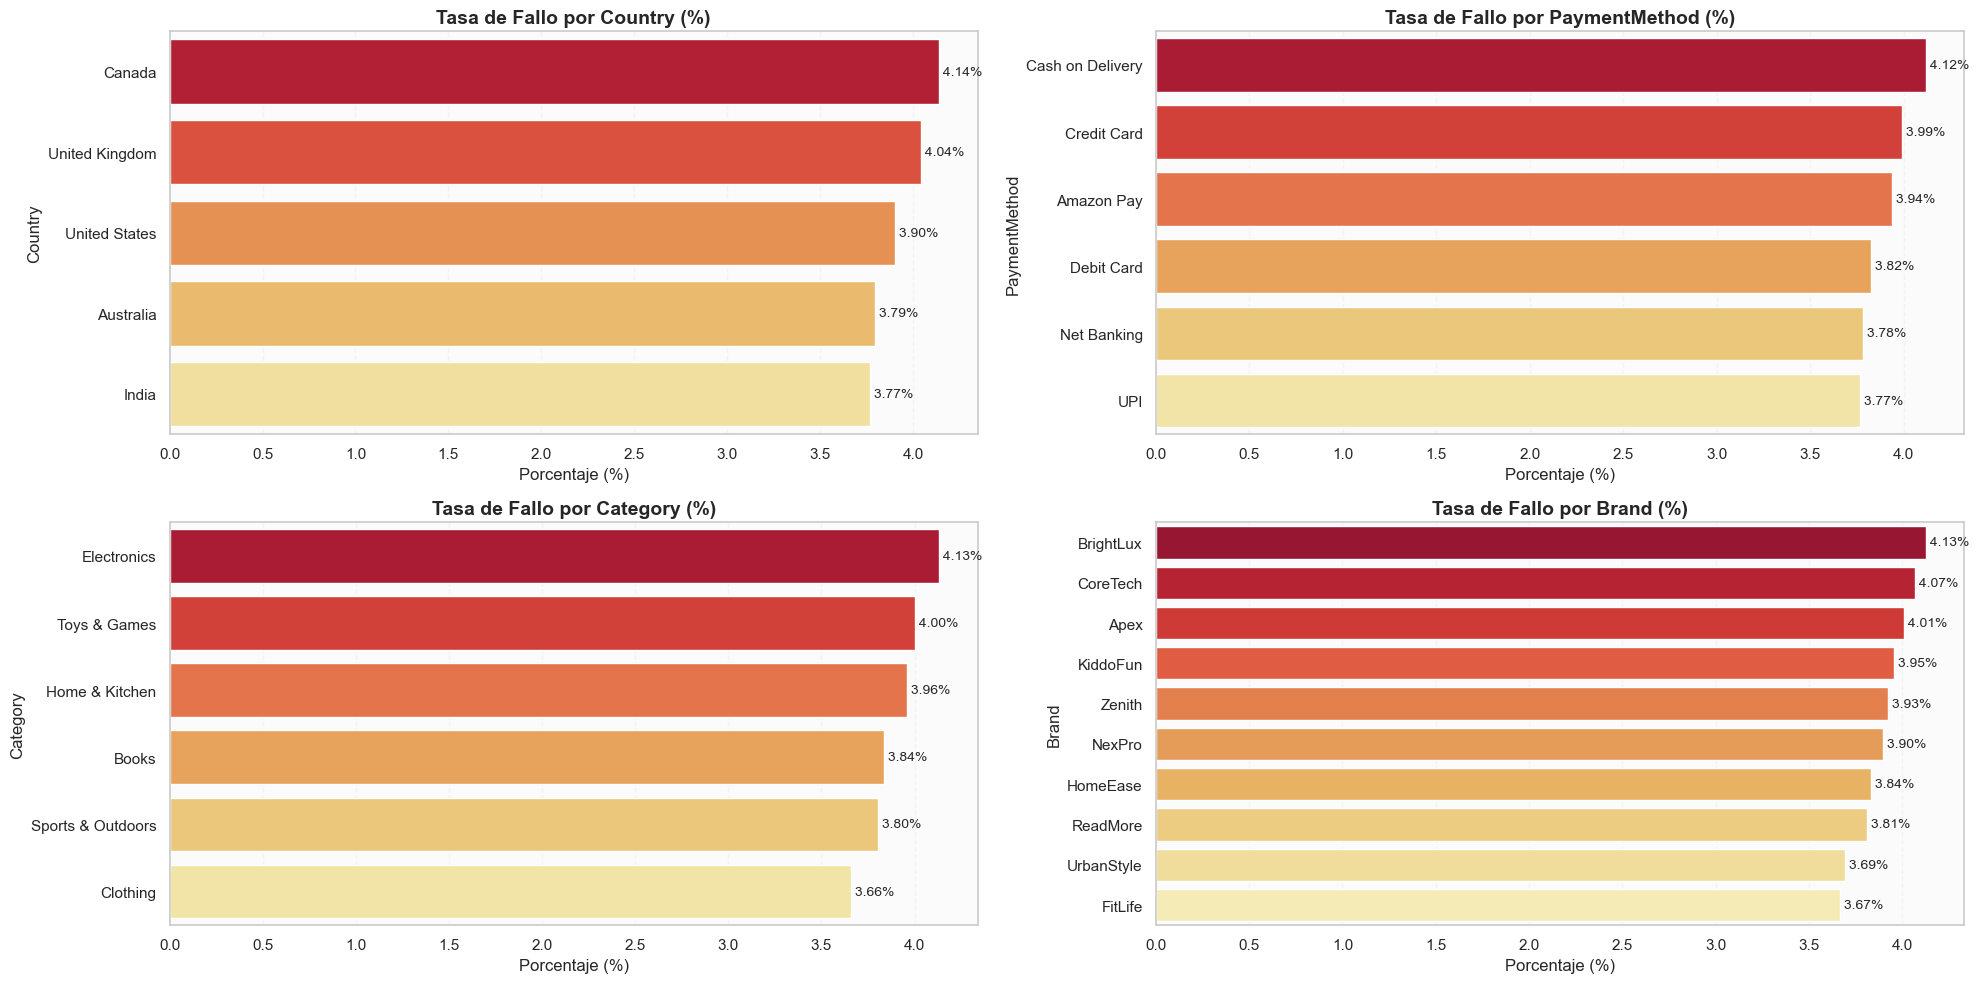

In [11]:
features = ['Country', 'PaymentMethod', 'Category', 'Brand']

fig, axs = plt.subplots(2, 2, figsize=(20, 10))
axs = axs.flatten()

for i, col in enumerate(features):
    ratio_df = df_analisis.groupby(col)['target'].agg(['count', 'sum']).reset_index()
    ratio_df.columns = [col, 'Total', 'Fallos']
    ratio_df['Rate'] = (ratio_df['Fallos'] / ratio_df['Total']) * 100
    ratio_df = ratio_df.sort_values(by='Rate', ascending=False)

    sns.barplot(data=ratio_df, x='Rate', y=col, ax=axs[i], palette='YlOrRd_r', hue=col, legend=False)
    for index, value in enumerate(ratio_df['Rate']):
        axs[i].text(value, index, f' {value:.2f}%', va='center', fontsize=10)

    axs[i].set_title(f'Tasa de Fallo por {col} (%)', fontsize=14, fontweight='bold')
    axs[i].set_xlabel('Porcentaje (%)')
    axs[i].set_ylabel(col)
    axs[i].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Al observar los ratios de cancelación, notamos que las diferencias porcentuales entre las distintas categorías son pequeñas, moviéndose todas en un rango de entre el 3.6% y el 4.2%. Sin embargo, este análisis nos permite confirmar que el volumen de pedidos no siempre equivale a una mayor ineficiencia; por ejemplo, aunque Estados Unidos es el país con más ventas, Canadá y el Reino Unido presentan tasas de cancelación ligeramente superiores (superando el 4%). Asimismo, identificamos que el método de pago "Cash on Delivery" y la categoría de "Electronics" son los que tienen mayor tendencia a ser cancelados. Estos resultados demuestran que las pérdidas se distribuyen de manera muy equilibrada, pero con puntos específicos de atención en cada variable.

Una vez identificadas las tasas de fallo para estas dimensiones, el siguiente paso consistirá en generar una gráfica de ranking de relevancia de variables. Mediante esta gráfica, podremos determinar qué factores del conjunto de datos tienen un mayor peso y correlación con nuestra variable objetivo (target). No obstante, es importante no depender exclusivamente de lo que muestre esta gráfica, ya que las variables categóricas se transforman en variables numéricas con el método de 'LabelEncoder', lo que hace que a unos datos se les de más importancia que a otros; también consideraremos realizar pruebas con variables que tengan un valor menor en el ranking, ya que, al combinarse con otros datos, podrían aportar un valor inesperado y ayudar a mejorar el rendimiento de los modelos más de lo previsto inicialmente.

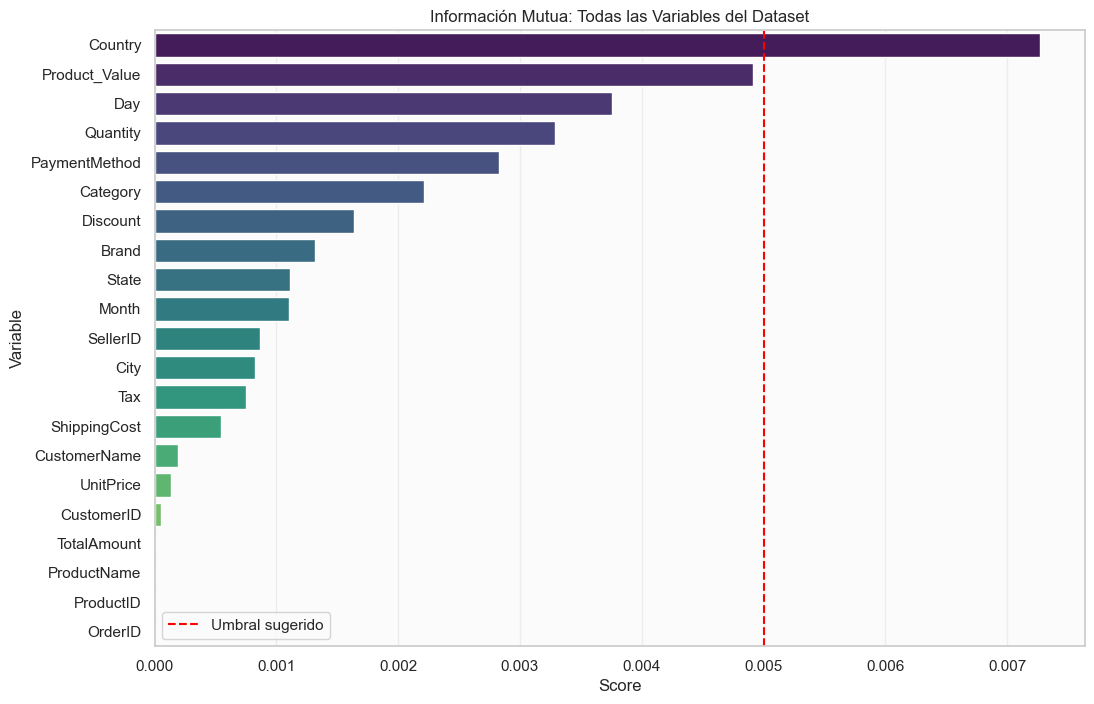

In [12]:
df_analysis = df_analisis.copy()

# 1. Convertimos temporalmente los textos a números para el cálculo
le = LabelEncoder()
for col in df_analysis.select_dtypes(include=['object', 'category']).columns:
    df_analysis[col] = le.fit_transform(df_analysis[col].astype(str))

# 2. Definimos X  para todas las variables y Y como la variable objetivo
X_all = df_analysis.drop(columns=['target', 'OrderStatus', 'OrderDate'])
y_all = df_analysis['target']

# 3. Calcular Mutual Information
importances_all = mutual_info_classif(X_all, y_all, random_state=42)

# 4. Crear el DataFrame para despues graficar los resultados
mi_all_df = pd.DataFrame({'Variable': X_all.columns, 'Score': importances_all})
mi_all_df = mi_all_df.sort_values(by='Score', ascending=False)

# 5. Graficar
plt.figure(figsize=(12, 8))
sns.barplot(x='Score', y='Variable', hue = 'Variable', data=mi_all_df, palette='viridis')
plt.title('Información Mutua: Todas las Variables del Dataset')
plt.axvline(x=0.005, color='red', linestyle='--', label='Umbral sugerido')
plt.legend()
plt.show()

A través de esta última gráfica se observa un punto crítico: únicamente una variable logra superar el umbral sugerido para la selección automática de características. Como se mencionó anteriormente, es muy probable que este resultado sea consecuencia de la codificación mediante **LabelEncoder**, técnica que puede asignar un peso jerárquico arbitrario a los datos y distorsionar su importancia real. Por esta razón, en lugar de seguir estrictamente el umbral, hemos decidido seleccionar las variables que presentan los valores más altos en la gráfica, integrando este criterio con las conclusiones obtenidas en el análisis exploratorio previo para garantizar que no se pierda información valiosa.

Una vez definida la selección de características, daremos inicio a la etapa de transformación y división de los datos. Este paso es fundamental para preparar la estructura final del dataset y separar la información en conjuntos de entrenamiento y prueba. Con esto, procederemos a construir y evaluar diversos modelos de clasificación en el notebook siguiente, con el objetivo de identificar cuál de ellos ofrece el mejor rendimiento y la mayor precisión al predecir nuestra variable objetivo.